# 04 — Selected-dataset diagnostic experiments
Run All: shared dataset (Kinetics subset default) → validation screen → longer/finer training → freeze → final test metrics → test videos. No execution toggles or pasted run directories. Saved outputs below belong to the earlier VDD run, not Kinetics.

Despite its retained filename, this is an exploratory single-seed diagnostic, **not the controlled AAD paper protocol**. The original `aad_experiment_workflow.ipynb`, AAD configs and CLIs remain separate and unchanged. Do not tune models from test results.

In [12]:
from pathlib import Path
import subprocess
import sys
import importlib

REPO_ROOT = Path('/content/phd_research')
if not REPO_ROOT.is_dir():
    subprocess.run(['git', 'clone', 'https://github.com/sanelehlabisa/phd_research.git', str(REPO_ROOT)], check=True)
else:
    update = subprocess.run(['git', 'pull', '--ff-only', 'origin', 'master'], cwd=REPO_ROOT, capture_output=True, text=True)
    print(update.stdout, flush=True)
    if update.returncode:
        raise RuntimeError('Cannot safely update the Colab checkout. Save/commit conflicting local edits, resolve the Git error, then rerun setup. No local edits were discarded.\n' + update.stderr)
IMPLEMENTATION_ROOT = REPO_ROOT / 'papers/001-journal-abnormal-activity-recognition/implementation'
required_helpers = ('notebook_data.py', 'notebook_display.py', 'notebook_workflows.py')
missing_helpers = [name for name in required_helpers if not (IMPLEMENTATION_ROOT / 'src' / name).is_file()]
revision = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'], cwd=REPO_ROOT, capture_output=True, text=True, check=True).stdout.strip()
print(f'Code checkout: {REPO_ROOT} @ {revision}', flush=True)
if missing_helpers:
    raise RuntimeError(f'Colab checkout is missing repository files: {missing_helpers}. These are NOT pip packages. Commit and push the complete notebook/source update to master, then rerun this setup cell. A kernel restart alone cannot download unpublished files.')
bootstrap = subprocess.run([sys.executable, str(IMPLEMENTATION_ROOT / 'src/colab_bootstrap.py'), str(IMPLEMENTATION_ROOT / 'requirements.txt')])
if bootstrap.returncode == 75:
    raise SystemExit('Restart the Colab runtime, reconnect to the A100, and rerun from the top.')
bootstrap.check_returncode()
sys.path[:] = [str(IMPLEMENTATION_ROOT)] + [entry for entry in sys.path if entry != str(IMPLEMENTATION_ROOT)]
for name in [name for name in sys.modules if name == 'src' or name.startswith('src.')]:
    del sys.modules[name]
importlib.invalidate_caches()
from src.notebook_utils import validate_runtime
print(validate_runtime(require_cuda=True))
from src.notebook_data import prepare_data
prepared = prepare_data(IMPLEMENTATION_ROOT)


Already up to date.

Code checkout: /content/phd_research @ 57bd8fb
{'python': '3.13.15', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39', 'pytorch': '2.9.1+cu128', 'torchvision': '0.24.1+cu128', 'cuda_available': True, 'cuda_version': '12.8', 'cudnn_version': 91002, 'cuda_device': 'NVIDIA A100-SXM4-80GB'}
Dataset: vdd | sanelehlabisa/violence-detection-dataset
Accepted classes: ('non-violent', 'violent')
Downloading/reusing Kaggle cache (download/extraction may take time)...
Using Colab cache for faster access to the 'violence-detection-dataset' dataset.
Locating class folders and building file inventory (no video decoding)...
✅ 350 videos | mode=video | 2 classes: ['non-violent', 'violent']
Ready in 23.1s | train=244, validation=53, test=53 (locked)


## Declared candidate budgets
Three architectures, eight epochs each at 32×32; same split, seed and input budget. Rank on validation macro-F1, accuracy, parameter count, then name. Checkpoints within each run use validation loss.

In [13]:
from src.notebook_workflows import show_experiment_plan, run_screen, train_winner, final_evaluate
screen_dir = final_data = None  # Clear any previous run before starting.
plan = show_experiment_plan(prepared)


,candidate,layers,epochs,resolution,frames,batch,learning_rate,seed
0,width_8,"[[8, [3, 3]]]",8,32x32,16,8,0.001,42
1,depth_8_16,"[[8, [3, 3]], [16, [3, 3]]]",8,32x32,16,8,0.001,42
2,depth_8_8_8,"[[8, [3, 3]], [8, [3, 3]], [8, [3, 3]]]",8,32x32,16,8,0.001,42


Then retrain the validation winner from scratch: 24 epochs, 64x64; freeze before final test.
Exploratory single-seed diagnostic, not the controlled AAD paper screen.


Candidate 1/3: width_8
Training width_8 on cuda: 8 epochs, 32x32, ((8, (3, 3)),)
Artifacts: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180807_493478_violence-detection-dataset_width_8
Epoch 1/8
  width_8: 8/244 clips | batch loss=0.7053


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  width_8: 244/244 clips | batch loss=0.6276
  Validating complete validation partition...
  width_8: 53/53 clips | batch loss=0.6070
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180807_493478_violence-detection-dataset_width_8/checkpoints/best_model.pth
  train loss=0.6819, acc=63.1% | val loss=0.6670, acc=66.0%


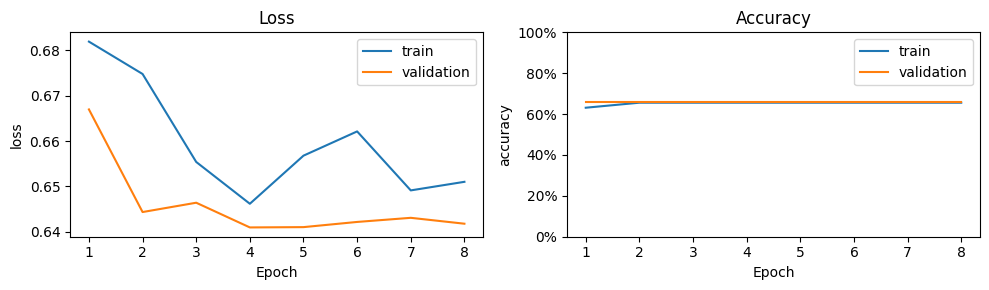

Epoch 2/8
  width_8: 244/244 clips | batch loss=0.7866
  Validating complete validation partition...
  width_8: 53/53 clips | batch loss=0.4915
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180807_493478_violence-detection-dataset_width_8/checkpoints/best_model.pth
  train loss=0.6748, acc=65.6% | val loss=0.6443, acc=66.0%
Epoch 3/8
  width_8: 244/244 clips | batch loss=0.7567
  Validating complete validation partition...
  width_8: 53/53 clips | batch loss=0.5048
  train loss=0.6554, acc=65.6% | val loss=0.6464, acc=66.0%
Epoch 4/8
  width_8: 244/244 clips | batch loss=0.6490
  Validating complete validation partition...
  width_8: 53/53 clips | batch loss=0.4525
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180807_493478_violence-detection-dataset_width_8/checkpoints/best_model.pth
  train loss=0.6462, acc=65.6% | val los

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  depth_8_16: 244/244 clips | batch loss=0.2767
  Validating complete validation partition...
  depth_8_16: 53/53 clips | batch loss=0.3061
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180819_991517_violence-detection-dataset_depth_8_16/checkpoints/best_model.pth
  train loss=0.6851, acc=48.0% | val loss=0.6525, acc=66.0%


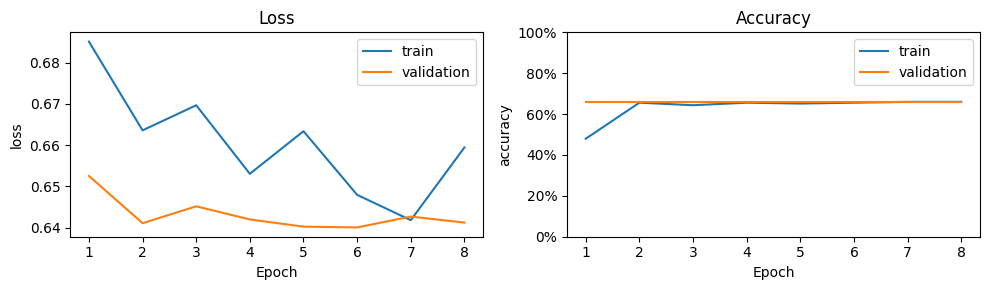

Epoch 2/8
  depth_8_16: 244/244 clips | batch loss=0.7508
  Validating complete validation partition...
  depth_8_16: 53/53 clips | batch loss=0.4534
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180819_991517_violence-detection-dataset_depth_8_16/checkpoints/best_model.pth
  train loss=0.6636, acc=65.6% | val loss=0.6411, acc=66.0%
Epoch 3/8
  depth_8_16: 244/244 clips | batch loss=0.8931
  Validating complete validation partition...
  depth_8_16: 53/53 clips | batch loss=0.4932
  train loss=0.6697, acc=64.3% | val loss=0.6452, acc=66.0%
Epoch 4/8
  depth_8_16: 244/244 clips | batch loss=0.6403
  Validating complete validation partition...
  depth_8_16: 53/53 clips | batch loss=0.4621
  train loss=0.6530, acc=65.6% | val loss=0.6420, acc=66.0%
Epoch 5/8
  depth_8_16: 244/244 clips | batch loss=0.5840
  Validating complete validation partition...
  depth_8_16: 53/53 clips | batch loss=0.4320
✅ Saved check

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  depth_8_8_8: 244/244 clips | batch loss=0.5264
  Validating complete validation partition...
  depth_8_8_8: 53/53 clips | batch loss=0.5188
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180829_731717_violence-detection-dataset_depth_8_8_8/checkpoints/best_model.pth
  train loss=0.6767, acc=65.2% | val loss=0.6482, acc=66.0%


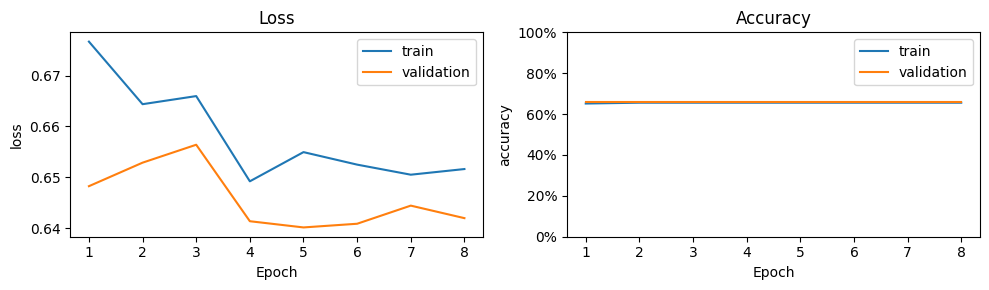

Epoch 2/8
  depth_8_8_8: 244/244 clips | batch loss=0.7533
  Validating complete validation partition...
  depth_8_8_8: 53/53 clips | batch loss=0.5421
  train loss=0.6644, acc=65.6% | val loss=0.6529, acc=66.0%
Epoch 3/8
  depth_8_8_8: 244/244 clips | batch loss=0.7486
  Validating complete validation partition...
  depth_8_8_8: 53/53 clips | batch loss=0.5580
  train loss=0.6660, acc=65.6% | val loss=0.6564, acc=66.0%
Epoch 4/8
  depth_8_8_8: 244/244 clips | batch loss=0.5687
  Validating complete validation partition...
  depth_8_8_8: 53/53 clips | batch loss=0.4535
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180829_731717_violence-detection-dataset_depth_8_8_8/checkpoints/best_model.pth
  train loss=0.6492, acc=65.6% | val loss=0.6413, acc=66.0%
Epoch 5/8
  depth_8_8_8: 244/244 clips | batch loss=0.6047
  Validating complete validation partition...
  depth_8_8_8: 53/53 clips | batch loss=0.4238
✅ Sa

,candidate,loss,accuracy,macro_precision,macro_recall,macro_f1,parameters
0,width_8,0.640955,0.660377,0.330189,0.5,0.397727,3218
1,depth_8_8_8,0.640114,0.660377,0.330189,0.5,0.397727,12498
2,depth_8_16,0.640031,0.660377,0.330189,0.5,0.397727,17122


In [14]:
screen_dir = run_screen(prepared)


## Longer training at finer resolution
Retrain the validation-selected architecture from scratch for 24 epochs at 64×64, then freeze its lowest-validation-loss checkpoint. A training stage, not a controlled resolution ablation.

Dataset: vdd | sanelehlabisa/violence-detection-dataset
Accepted classes: ('non-violent', 'violent')
Locating class folders and building file inventory (no video decoding)...
✅ 350 videos | mode=video | 2 classes: ['non-violent', 'violent']
Ready in 0.1s | train=244, validation=53, test=53 (locked)
Training width_8-longer on cuda: 24 epochs, 64x64, ((8, (3, 3)),)
Artifacts: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180843_751401_violence-detection-dataset_width_8-longer
Epoch 1/24
  width_8-longer: 8/244 clips | batch loss=0.7052


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  width_8-longer: 244/244 clips | batch loss=0.6271
  Validating complete validation partition...
  width_8-longer: 53/53 clips | batch loss=0.6065
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180843_751401_violence-detection-dataset_width_8-longer/checkpoints/best_model.pth
  train loss=0.6819, acc=63.1% | val loss=0.6669, acc=66.0%


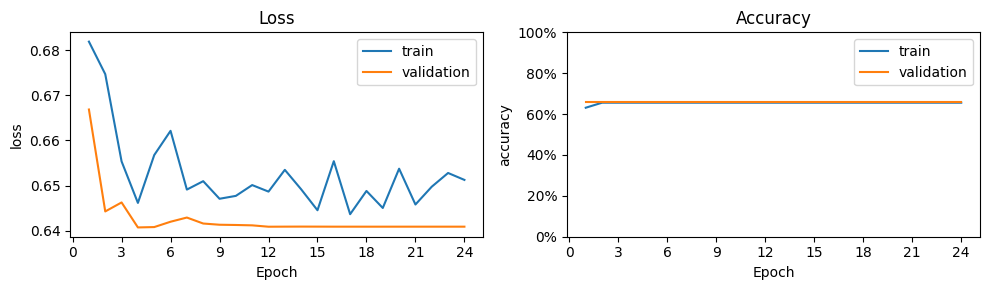

Epoch 2/24
  width_8-longer: 244/244 clips | batch loss=0.7864
  Validating complete validation partition...
  width_8-longer: 53/53 clips | batch loss=0.4919
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180843_751401_violence-detection-dataset_width_8-longer/checkpoints/best_model.pth
  train loss=0.6747, acc=65.6% | val loss=0.6443, acc=66.0%
Epoch 3/24
  width_8-longer: 244/244 clips | batch loss=0.7573
  Validating complete validation partition...
  width_8-longer: 53/53 clips | batch loss=0.5046
  train loss=0.6554, acc=65.6% | val loss=0.6463, acc=66.0%
Epoch 4/24
  width_8-longer: 244/244 clips | batch loss=0.6503
  Validating complete validation partition...
  width_8-longer: 53/53 clips | batch loss=0.4521
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_180843_751401_violence-detection-dataset_width_8-longer/checkpoi

In [15]:
final_data = train_winner(prepared, screen_dir)


## Final test metrics, then playable test predictions
Run All intentionally opens test only after the complete screen and compatible longer training. Full test metrics come before up to five test videos/probabilities. Rerunning this last cell reuses its saved report. Do not tune or rerank from test feedback.

In [16]:
final_report = final_evaluate(final_data, screen_dir)


Final evaluation: 53 test clips; model is frozen.
  Test: 8/53
  Test: 16/53
  Test: 24/53
  Test: 32/53
  Test: 40/53
  Test: 48/53
  Test: 53/53


,loss,accuracy,macro_precision,macro_recall,macro_f1
0,0.642038,0.660377,0.330189,0.5,0.397727


TypeError: stat: path should be string, bytes, os.PathLike or integer, not NoneType